In [255]:
import sys
import h5py
import numpy as np

# from cartopy import crs as ccrs
# from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter 

from matplotlib import colors as cm
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import sys
import os
import importlib.util

## Loading DATA

In [256]:
# parameters 
PR               = 0
level_index      = 5
file_path        = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF"


# define variables
lat              = np.linspace(-90, 90, 64)
lat_cond         = np.where((lat>=-15)&(lat<=15))[0]
var              = {}
var_list         = {'p','prec','u','v'}
for index, var_i in enumerate(var_list):
    with h5py.File(f"{file_path}/PR{PR}/{var_i}/PR{PR}_500_20000day_6hourly_{var_i}.dat") as f:
        if var_i == 'prec':
            var[f"{var_i}"] = f[var_i][:, :,:]*86400
        else:
            var[f"{var_i}"] = f[var_i][:, level_index, :]


## Wheeler and Kiladis (1999) Calculation



### Defining function

In [257]:
import warnings
del FFT2D
def FFT2D(data,dim_time,dim_lon): 
    # input data should have dimension of [time X lon] (even only)
    # dim_time = the dimension of time
    # dim_lon  = the dimension of lon

    if ((dim_time % 2) != 0) or ((dim_lon % 2) != 0):
       print("input dimension is not even")
    else:
       print("pass dimension check")
    C_k = np.zeros((dim_time,int(dim_lon/2))) 
    S_k = np.zeros((dim_time,int(dim_lon/2)))
    
    
    for i in range(dim_time):
        fourier_coeffs           = np.fft.fft(data[i,:])
        C_k[i,1:]                = np.real(fourier_coeffs[1:int(dim_lon/2)]*2)/(dim_lon)
        S_k[i,1:]                = np.imag(fourier_coeffs[1:int(dim_lon/2)]*2)/(dim_lon)

    A_kw = np.zeros((int(dim_time/2),int(dim_lon/2))) 
    B_kw = np.zeros((int(dim_time/2),int(dim_lon/2)))
    a_kw = np.zeros((int(dim_time/2),int(dim_lon/2))) 
    b_kw = np.zeros((int(dim_time/2),int(dim_lon/2))) 
    fourier_coeffs_kw = np.zeros((2,C_k.shape[0],C_k.shape[1])) # first dimension: cos and sin, second dimension: frequency, third dimension: wave number
    
    for i in range(int(dim_lon/2)):
        fourier_coeffs           = np.fft.fft(C_k[:,i])
        fourier_coeffs_kw[0,:,i] = fourier_coeffs*2/dim_time
        A_kw[:,i]                = np.real(fourier_coeffs[:int(dim_time/2)]*2)/(dim_time)
        B_kw[:,i]                = np.imag(fourier_coeffs[:int(dim_time/2)]*2)/(dim_time)
        fourier_coeffs           = np.fft.fft(S_k[:,i])
        a_kw[:,i]                = np.real(fourier_coeffs[:int(dim_time/2)]*2)/(dim_time)
        b_kw[:,i]                = np.imag(fourier_coeffs[:int(dim_time/2)]*2)/(dim_time)

    return A_kw, B_kw, a_kw, b_kw


# def FFT2D_ifft(A_kw, B_kw, a_kw, b_kw, direction="all"): 
#     if direction=="west":
#         sign = 1
#     elif direction=='east':
#         sign = -1
#     else: 
#         sign = 1
        
#     dim_time       = (A_kw.shape[0])*2
#     dim_lon        = (A_kw.shape[1])*2
#     C_k            = np.zeros((dim_time,A_kw.shape[1] ))
#     S_k            = np.zeros((dim_time,A_kw.shape[1] ))
#     data           = np.zeros((dim_time,dim_lon))
    
#     for k in range(A_kw.shape[1]):
#         fourier_coefficients                    = np.zeros((dim_time,)).astype('complex')
#         fourier_coefficients[:A_kw.shape[0],]   = A_kw[:,k]+sign*1j*B_kw[:,k]
#         fourier_coefficients[A_kw.shape[0]+1:,] = (A_kw[1:,k]-sign*1j*B_kw[1:,k])[::-1]
#         fourier_coefficients[A_kw.shape[0]:A_kw.shape[0]+1,] =  A_kw[-1,k]-sign*1j*B_kw[-1,k]       
        
#         C_k[:,k]                                = np.fft.ifft(fourier_coefficients/2*dim_time)

        
#         fourier_coefficients                    = np.zeros((dim_time,)).astype('complex')
#         fourier_coefficients[:A_kw.shape[0],]   = a_kw[:,k]+1j*b_kw[:,k]
#         fourier_coefficients[A_kw.shape[0]+1:,] = (a_kw[1:,k]-1j*b_kw[1:,k])[::-1]
#         fourier_coefficients[A_kw.shape[0]:A_kw.shape[0]+1,] =  a_kw[-1,k]-1j*b_kw[-1,k]      
#         S_k[:,k]                                = np.fft.ifft(fourier_coefficients/2*dim_time)

#     for t in range(dim_time):
#         fourier_coefficients                    = np.zeros((dim_lon,)).astype('complex')
#         fourier_coefficients[:A_kw.shape[1],]   = C_k[t,:]+sign*1j*S_k[t,:]
#         fourier_coefficients[A_kw.shape[1]+1:,] = (C_k[t,1:]-sign*1j*S_k[t,1:])[::-1]
#         fourier_coefficients[A_kw.shape[1]:A_kw.shape[1]+1,] =  C_k[t,-1]-sign*1j*S_k[t,-1]       
#         data[t,:]                               = np.fft.ifft(fourier_coefficients/2*dim_lon)

    
#     return C_k, S_k, data

def space_time_recon(var,wnm_ref,frm_ref,direction): 
    if var.ndim ==3:
        # input should have a dimension of time, lat, lon
        dim_time = int(var.shape[0])
        dim_lat  = int(var.shape[1])
        dim_lon  = int(var.shape[2])
        # ================= #
        # # FFT
        var_fft = np.array([
            np.fft.fftshift(np.fft.fft2(var[:,i,:]))
            for i in range(dim_lat)
            ])
    
        # # dimension for bandpass filter
        wn = np.linspace(-dim_lon/2,  dim_lon/2-1, dim_lon)
        fr = np.linspace(-dim_time/2, dim_time/2-1, dim_time)
    
        wnm, frm = np.meshgrid(wn, fr)
    
        if direction=='west':
            cond = np.logical_or.reduce([
                wnm < wnm_ref,  wnm >= wnm_ref+1,
                frm < frm_ref,  frm >= (frm_ref+1),
                ])
        elif direction=='east':
            cond = np.logical_or.reduce([
                wnm > -wnm_ref,  wnm <= -(wnm_ref+1),
                frm < frm_ref,  frm >= (frm_ref+1),
                ])
        #ed8  = th.Wave(wnm, 8)
        #ed90 = th.Wave(wnm, 90)
    
        # cond = np.logical_or.reduce([
        #     wnm < 1, wnm > 14,
        #     frm < 1/20, frm > 1/2.5,
        #     frm < ed8.Kelvin(), frm > ed90.Kelvin()
        #     ])
    
        # # bandpass filter and inverse FFT
        # # # IFFT
        var_ifft = []
        
    
        for i in range(dim_lat):
            var_filted = np.where(cond == True, 0, var_fft[i]*2)
            var_ifft.append(np.fft.ifft2(np.fft.ifftshift(var_filted)))
    
    
        # # # reconstruct
        var_recon = np.array(np.real(np.stack(var_ifft, axis=1)))
        
    elif var.ndim==2:
        # input should have a dimension of time, lat, lon
        dim_time = int(var.shape[0])
        dim_lon  = int(var.shape[1])
        # ================= #
        # # FFT
        var_fft = np.array([
            np.fft.fftshift(np.fft.fft2(var[:,:]))
            ])
    
        # # dimension for bandpass filter
        wn = np.linspace(-dim_lon/2,    (dim_lon/2-1), dim_lon)
        fr = np.linspace(-dim_time/2,   dim_time/2-1, dim_time)
        print(wn)
        wnm, frm = np.meshgrid(wn, fr)

        if direction=='west':
            cond = np.logical_or.reduce([
                wnm < wnm_ref,  wnm >= wnm_ref+1,
                frm < frm_ref,  frm >= (frm_ref+1),
                ])
        elif direction=='east':
            cond = np.logical_or.reduce([
                wnm > -wnm_ref,  wnm <= -(wnm_ref+1),
                frm < frm_ref,  frm >= (frm_ref+1),
                ])

        var_ifft = []
        
    
        
        var_filted = np.where(cond == True, 0, var_fft)
        var_ifft.append(np.fft.ifft2(np.fft.ifftshift(var_filted*2)))
    
    
        # # # reconstruct
        var_recon       = np.squeeze(np.real(var_ifft))
        #var_recon_total = np.fft.ifft2(np.fft.ifftshift(var_fft))
    return var_recon
    
# making chunks
def split_with_overlap(data, chunk_size):
    """
    Splits data into chunks with 50% overlap.
    
    Args:
        data (list or array): The input data to be split.
        chunk_size (int): The size of each chunk.
    
    Returns:
        list: A list of chunks with 50% overlap.
    """
    step   = chunk_size // 2
    chunks = [data[i:i + chunk_size,:] for i in range(0, data.shape[0] - chunk_size + 1, step)]
    return np.array(chunks)

# making daily data
def average_every_n_steps(data, n):
    """
    Calculate the average for every n steps in the data.
    
    Args:
        data (list or array): Input data.
        n (int): Number of steps for each group.
    
    Returns:
        list: A list of averages for every n steps.
    """
    averages = [sum(data[i:i + n,:]) / len(data[i:i + n]) for i in range(0, data.shape[0], n)]
    return np.array(averages)



def making_theoretical_line():
    beta = 2.289*10**(-11)

    for h in [12,25,50]: # equivalent depth
        c  = np.sqrt(9.8*h)
        #c    = 50
        
        # Define the wave number array
        k = np.arange(-14, 14.01, 0.01)/(6371*10**3)
        K_size = np.size(k)
        K_size_half = int((K_size-1)/2)
        
        # Calculate omega1 and omega2
        omega1 = np.zeros(K_size)
        omega2 = np.zeros(K_size)
        for i in range(K_size):
            omega1[i] = k[i]*c / 2 * (1 + (1 + 4*beta*c/(k[i] ** 2*c**2)) ** 0.5)
            omega2[i] = k[i]*c / 2 * (1 - (1 + 4*beta*c/(k[i] ** 2*c**2)) ** 0.5)
        
        # Calculate omega3, omega4, and omega5
        omega3 = np.zeros(K_size)
        omega4 = np.zeros(K_size)
        omega5 = np.zeros(K_size)
        for i in range(K_size):
            omega3[i] = -k[i]*beta / (k[i] ** 2 + 3*beta/c)
            omega4[i] = -k[i]*beta / (k[i] ** 2 + 3*beta/c)
            omega5[i] = -k[i]*beta / (k[i] ** 2 + 3*beta/c)
        
        # Calculate omega6, omega7, and omega8
        omega6 = np.sqrt(2*beta*c + k ** 2*c**2)
        omega7 = np.sqrt(3*beta*c + k ** 2*c**2)
        omega8 = np.sqrt(4*beta*c + k ** 2*c**2)
    
        # Calculate Kelvin
        Omega_Kelvin = k*c
        
        k = np.arange(-14, 14.01, 0.01)
        # Plot the result
        plt.plot(k[K_size_half+1:], omega1[K_size_half+1:]*86400/(2*np.pi), 'k', label='mixed Rossby gravity wave')
        plt.plot(k[0:K_size_half],  omega2[0:K_size_half]*86400/(2*np.pi),  'k')
        plt.plot(k[0:K_size_half],  omega3[0:K_size_half]*86400/(2*np.pi),  'r-',label='equatorial Rossby wave')
        # plt.plot(k[0:300], omega4[0:300]*86400/(2*np.pi), 'r-.',label='equatorial rossby wave n=2')
        # plt.plot(k[0:300], omega5[0:300]*86400/(2*np.pi), 'r',label='equatorial rossby wave n=3')
        plt.plot(k[K_size_half:], k[K_size_half:]*c/(6371*10**3)*86400/(2*np.pi), 'b-', label='Kelvin Wave with')
        #plt.plot(k[K_size_half:], k[K_size_half:]*c/(6371*10**3), 'b-', label='Kelvin Wave with k=w')
        print(k[K_size_half:]/np.sqrt(c/beta)*86400)
        plt.plot(k, omega6*86400/(2*np.pi), color='gray',label='inertia gravity wave')
        # plt.plot(k[0:601], omega7[0:601], 'b-.',label='inertia gravity wave n=2')
        # plt.plot(k[0:601], omega8[0:601], 'b',label='inertia gravity wave n=3')
        if h==12:
            plt.legend(loc='upper left')




### calculation

In [258]:
prec_daily             = average_every_n_steps(var["prec"][:,:,:],4)   # making daily data
prec_daily_chunk       = split_with_overlap(prec_daily,50)             # 50-day window as the chunk size
print("dimension of prec_daily_chunk is"+str(prec_daily_chunk.shape))
dim_chunk, dim_time, dim_lat, dim_lon      = prec_daily_chunk.shape

# testing 
A_kw, B_kw, a_kw, b_kw = FFT2D(prec_daily_chunk[0,:,0,:],dim_time,dim_lon)

dimension of prec_daily_chunk is(779, 50, 64, 128)
pass dimension check


/tmp/ipykernel_771560/276138785.py:29: ComplexWarning: Casting complex values to real discards the imaginary part
  fourier_coeffs_kw[0,:,i] = fourier_coeffs*2/dim_time


In [259]:

# P_T  is the power spectrum of temperature 
# P_Q1 is the power spectrum of Q1
P_T     = np.zeros([2,A_kw.shape[0],A_kw.shape[1]]) # eastward/westward, wave number, frequency

count   = 0
for i in range(dim_chunk):
    A_kw, B_kw, a_kw, b_kw   = FFT2D(prec_daily_chunk[i,:,lat_cond.min():lat_cond.max(),:].mean(axis=1),dim_time,dim_lon)
    P_T[0,:,:]               = ((1/8*(A_kw**2+B_kw**2)+1/8*(a_kw**2+b_kw**2)+1/4*(a_kw*B_kw-A_kw*b_kw))+P_T[0,:,:]*count)/(count+1)
    P_T[1,:,:]               = ((1/8*(A_kw**2+B_kw**2)+1/8*(a_kw**2+b_kw**2)-1/4*(a_kw*B_kw-A_kw*b_kw))+P_T[1,:,:]*count)/(count+1)
    # A_kw, B_kw, a_kw, b_kw = FFT2D(np.array(data['q1pc1'][i,:,:,:]).mean(axis=1),dim_time,dim_lon)
    # P_Q1[0,:,:]              = ((1/8*(A_kw**2+B_kw**2)+1/8*(a_kw**2+b_kw**2)+1/4*(a_kw*B_kw-A_kw*b_kw))+P_Q1[0,:,:]*count)/(count+1)
    # P_Q1[1,:,:]              = ((1/8*(A_kw**2+B_kw**2)+1/8*(a_kw**2+b_kw**2)-1/4*(a_kw*B_kw-A_kw*b_kw))+P_Q1[1,:,:]*count)/(count+1)
    count = count+1

pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimensio

/tmp/ipykernel_771560/276138785.py:29: ComplexWarning: Casting complex values to real discards the imaginary part
  fourier_coeffs_kw[0,:,i] = fourier_coeffs*2/dim_time


pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimension check
pass dimensio

[-3.74605632e-14  1.25526323e-03  2.51052647e-03 ...  1.75485800e+00
  1.75611326e+00  1.75736853e+00]
[-3.11806103e-14  1.04482876e-03  2.08965752e-03 ...  1.46067060e+00
  1.46171543e+00  1.46276026e+00]
[-2.62196635e-14  8.78592757e-04  1.75718551e-03 ...  1.22827267e+00
  1.22915127e+00  1.23002986e+00]


(0.0, 0.48)

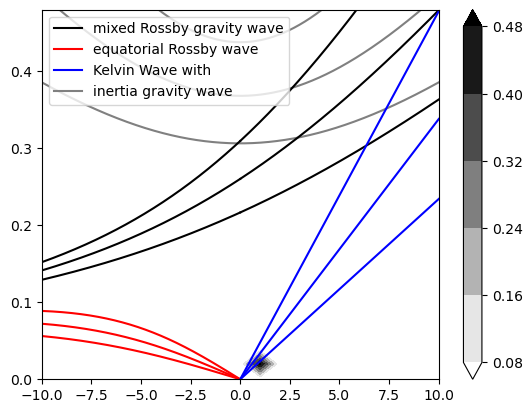

In [283]:
k_max       = 62
w_max       = 24

wave_number = np.arange(-k_max,k_max+1,1)
frequency   = np.arange(0,w_max,1)
k,w         = np.meshgrid(wave_number,frequency)

P_total = np.zeros((w_max,2*k_max+1))
P_total[:,k_max]         = (P_T[0,0:w_max,0]+P_T[1,0:w_max,0])
P_total[:,k_max+1:]      = P_T[0,0:w_max,1:k_max+1] 
P_total[:,k_max-1::-1]   = P_T[1,0:w_max,1:k_max+1] 

plt.figure()
making_theoretical_line()
cs=plt.contourf(-k,w/50,P_total[:,:],extend='both',cmap='gray_r')

plt.colorbar(cs)
plt.xlim([-10,10])
plt.ylim([0,24/50])

## Reconstruct the time series 

pass dimension check
pass dimension check


/tmp/ipykernel_771560/276138785.py:29: ComplexWarning: Casting complex values to real discards the imaginary part
  fourier_coeffs_kw[0,:,i] = fourier_coeffs*2/dim_time


(-3.0, 3.0)

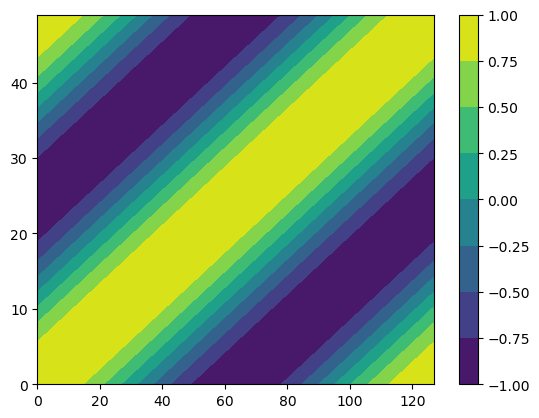

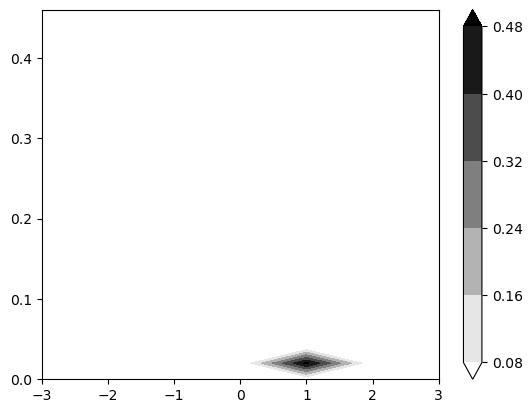

In [263]:
# Synethic Data 
x     = np.linspace(0,128,128)
t     = np.linspace(0,50,50)
xx,tt = np.meshgrid(x,t)


plt.figure()
cs=plt.contourf(np.cos(2*np.pi/128*(xx-tt/50*128)))
plt.colorbar(cs)
tmp     = np.cos(2*np.pi/128*(xx-tt/50*128))

A_kw, B_kw, a_kw, b_kw = FFT2D(tmp,dim_time,dim_lon)
P_T                    = np.zeros([2,A_kw.shape[0],A_kw.shape[1]]) # eastward/westward, wave number, frequency

count   = 0

## West component, B_kw, a_kw
## East component, A_kw, b_kw

#for i in range(dim_chunk):
for i in range(1):
    A_kw, B_kw, a_kw, b_kw   = FFT2D(tmp,dim_time,dim_lon)
    P_T[0,:,:]               = ((1/8*(A_kw**2+B_kw**2)+1/8*(a_kw**2+b_kw**2)+1/4*(a_kw*B_kw-A_kw*b_kw))+P_T[0,:,:]*count)/(count+1)
    P_T[1,:,:]               = ((1/8*(A_kw**2+B_kw**2)+1/8*(a_kw**2+b_kw**2)-1/4*(a_kw*B_kw-A_kw*b_kw))+P_T[1,:,:]*count)/(count+1)
P_total = np.zeros((w_max,2*k_max+1))
P_total[:,k_max]         = (P_T[0,0:w_max,0]+P_T[1,0:w_max,0])
P_total[:,k_max+1:]      = P_T[0,0:w_max,1:k_max+1] 
P_total[:,k_max-1::-1]   = P_T[1,0:w_max,1:k_max+1] 
plt.figure()
cs=plt.contourf(-k,w/50,P_total[:,:],extend='both',cmap='gray_r')
plt.colorbar(cs)
plt.xlim([-3,3])

[-64. -63. -62. -61. -60. -59. -58. -57. -56. -55. -54. -53. -52. -51.
 -50. -49. -48. -47. -46. -45. -44. -43. -42. -41. -40. -39. -38. -37.
 -36. -35. -34. -33. -32. -31. -30. -29. -28. -27. -26. -25. -24. -23.
 -22. -21. -20. -19. -18. -17. -16. -15. -14. -13. -12. -11. -10.  -9.
  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.   2.   3.   4.   5.
   6.   7.   8.   9.  10.  11.  12.  13.  14.  15.  16.  17.  18.  19.
  20.  21.  22.  23.  24.  25.  26.  27.  28.  29.  30.  31.  32.  33.
  34.  35.  36.  37.  38.  39.  40.  41.  42.  43.  44.  45.  46.  47.
  48.  49.  50.  51.  52.  53.  54.  55.  56.  57.  58.  59.  60.  61.
  62.  63.]
(50, 128)


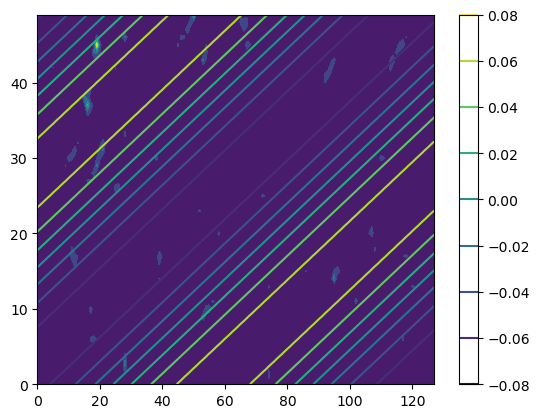

In [287]:
tmp_s  = prec_daily_chunk[i,:,lat_cond.min():32,:][:,::-1,:]
tmp_n  = prec_daily_chunk[i,:,32:lat_cond.max(),:]

# OLNY for U and P !!!
# find symmetric u(time, y, x) -> then fft -> do u' (time, y, x)
# 1. tmp_mean = (tmp_n - tmp_s) /2 # (time, 1, x) 
# 2. tmp_filter = space_time_recon(tmp_mean,wnm_ref=1,frm_ref=1,direction='east')
# 3. 
# tmp_filter_s = tmp_filter/2
# tmp_filter_n = tmp_filter/2

tmp_mean = (tmp_s + tmp_n) /2 

tmp_filter = space_time_recon(tmp_mean,wnm_ref=1,frm_ref=1,direction='east')
tmp_filter_s = tmp_filter/2
tmp_filter_n = tmp_filter/2 # == u'(time, (32-27), x)
"""
# 11/23 
# TODO: 1. first test wnm_ref=2,frm_ref=2 -> quiver(u', v')
# TODO: 2. for loop all over y -> u' (time, y, x)!!!
"""
print(tmp_filter_n.shape)
##################################################################################
# OLNY for V and vor !!!
# find symmetric v(time, y, x) -> then fft -> do v' (time, y, x)
# 1. tmp_mean = (tmp_n - tmp_s) /2 # (time, 1, x) 
# 2. tmp_filter = space_time_recon(tmp_mean,wnm_ref=1,frm_ref=1,direction='east')
# 3. 
# tmp_filter_s = -tmp_filter/2
# tmp_filter_n = tmp_filter/2


plt.figure()
cs=plt.contourf(tmp_mean)
cs=plt.contour(np.squeeze(tmp_filter))
plt.colorbar(cs)



In [274]:
tmp_filter_n.shape

(50, 128)

## using real precipitation data as example 

## Ccalculate Cross-spectrum 